# Child Food Allergy EDA

This notebook contains the exploratory data analysis cells split from `Child_Food_Allergy.ipynb`.


In [1]:
# packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML
HTML('''
<style>
div.input {display:none;}
</style>
''')

In [2]:
# read the original data
children = pd.read_csv('child24.csv')


In [3]:
# DEMOGRAPHICS

demographics = ["SEX_C", "RELTIVP_C", "RACEALLP_C"]

# MAIN OUTCOME
main_outcome = ["PHSTAT_C"]

# PSYCHOSOCIAL COVARIATES
psychosocial_covariates = ["ANXFREQ_C", "DEPFREQ_C", "SCHDYMSSTC_C"]

# SOCIAL DETERMINANTS OF HEALTH COVARIATES

# Income, Insurance

social_determinants = ["NOTCOV_C", "COVER_C", "FSNAP12M_C", "FWIC12M_C", "FLUNCH12M1_C"]

# Education
education = ["MAXPAREDUP_C"]

# Food Security

# FDSCAT34_C
food_security = ["FDSCAT3_C", "FDSCAT4_C"]

# Housing
housing = ["HOUTENURE_C"]

# Built Environment
built_environment = ["SIDEWALK_C", "PARKS_C", "TRAFFIC_C", "CRIME_C"]

# ELIGIBILITY
eligibility = ["AGEP_C", "CURFOOD_C"]

# Variables
variables = [
    *demographics,
    *main_outcome,
    *psychosocial_covariates,
    *social_determinants,
    *education,
    *food_security,
    *housing,
    *built_environment,
    *eligibility
]


child_data = children[variables]

In [4]:
# Limit the age range

children_with_age_range = child_data[
    child_data["AGEP_C"].between(5, 17)
]

# children_with_age_range

## Exploratory Data Analysis (EDA)   

### Sample Overview

- Total number of surveyed children
- The number of surveyed children in selected age range 5 to 17

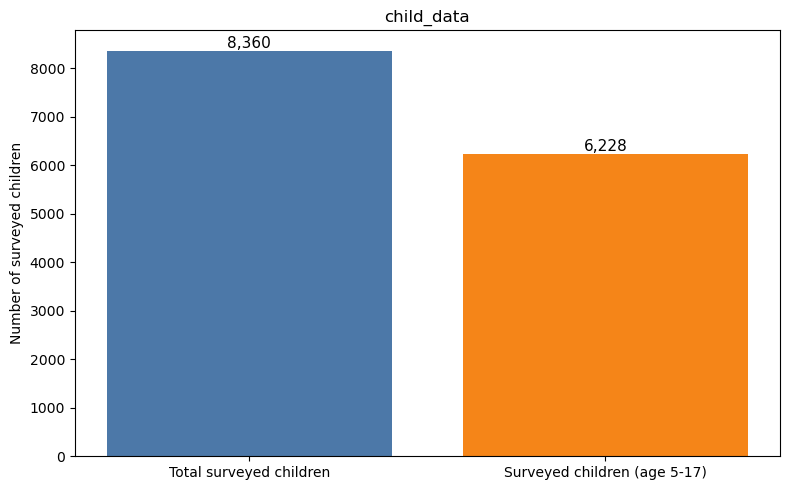

In [5]:
# Sample Overview

total_children = child_data.shape[0]
children_5_to_17 = children_with_age_range.shape[0]

sample_overview = pd.DataFrame({
    "Group": ["Total surveyed children", "Surveyed children (age 5-17)"],
    "Count": [total_children, children_5_to_17]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(sample_overview["Group"], sample_overview["Count"], color=["#4C78A8", "#F58518"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("child_data")
plt.ylabel("Number of surveyed children")
plt.xlabel("")
plt.tight_layout()
plt.show()


### Demographics

- The number of children by age
- The number of children by sex
- The number of children by race/ethnicity

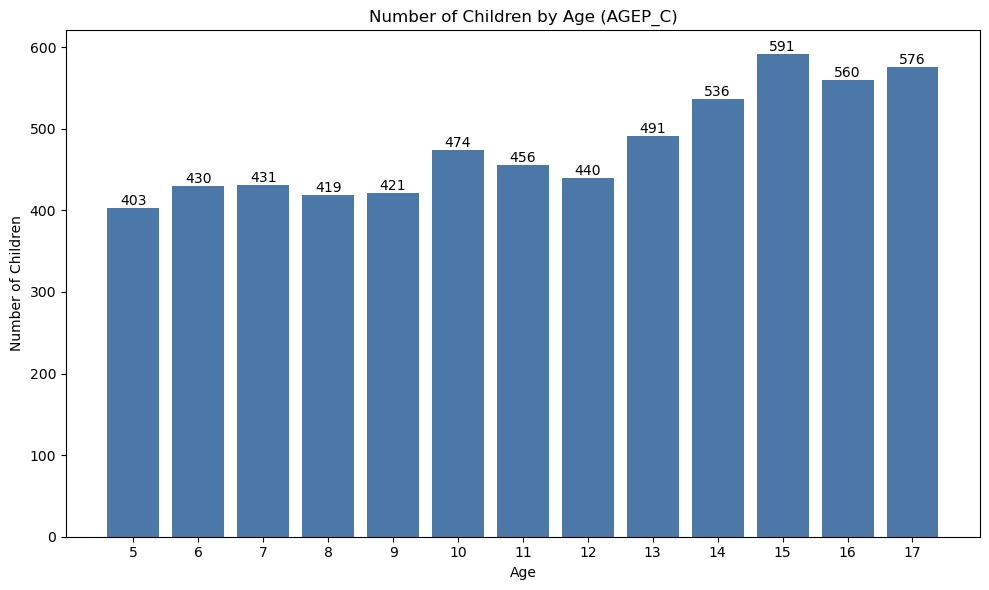

In [6]:
# Demographics - Bar chart 1: Number of children by age (5 to 17)

age_series = pd.to_numeric(child_data["AGEP_C"], errors="coerce")
age_5_to_17 = age_series[age_series.between(5, 17)]

# Keep all ages from 5 to 17 on the x-axis, filling missing ages with 0
age_counts = age_5_to_17.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts above each bar
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Age (AGEP_C)")
plt.xlabel("Age")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


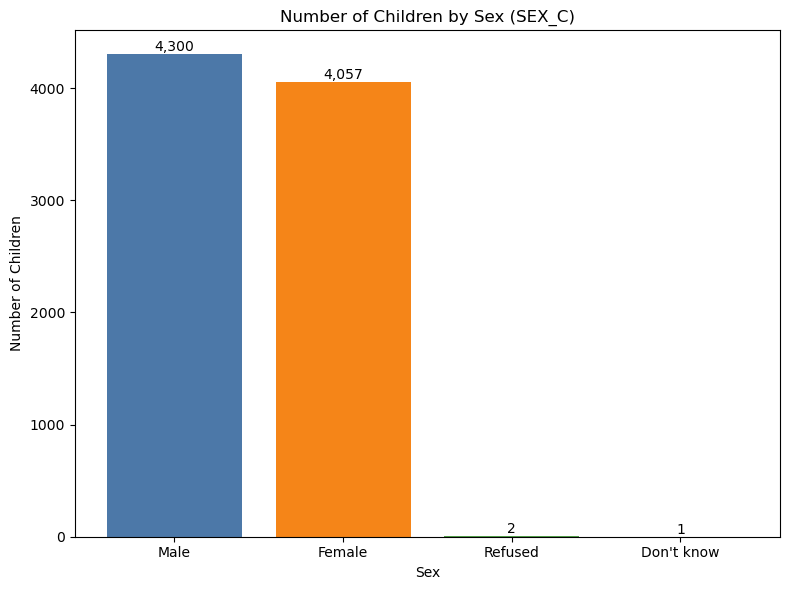

In [7]:
#| hide_input
# Demographics - Bar chart 2: Number of children by sex

sex_labels_map = {
    1: "Male",
    2: "Female",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

sex_series = pd.to_numeric(child_data["SEX_C"], errors="coerce")
sex_counts = sex_series.value_counts().sort_index()
sex_labels = [sex_labels_map.get(int(code), f"Code {int(code)}") for code in sex_counts.index]

# Use a different color for each bar
bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"][:len(sex_counts)]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Sex (SEX_C)")
plt.xlabel("Sex")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


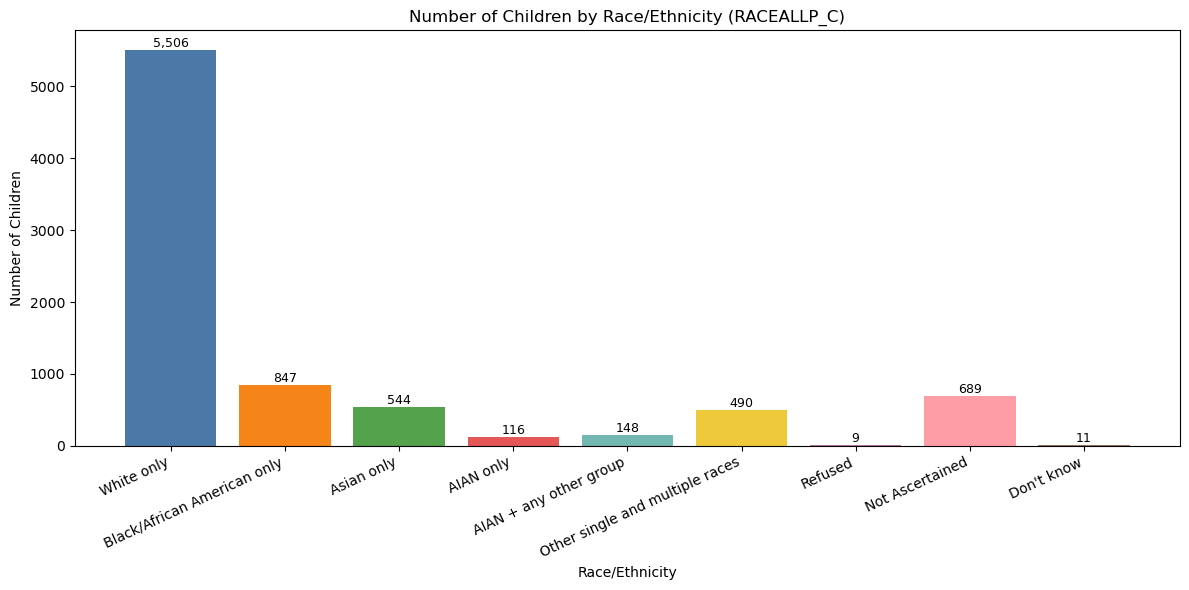

In [8]:
# Demographics - Bar chart 3: Number of children by race/ethnicity

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

race_series = pd.to_numeric(child_data["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

# Use a different color for each bar
bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children by Race/Ethnicity (RACEALLP_C)")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Number of Children")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Food Allergy

- The number of children with current food allergy (CURFOOD_C)
- Percentage of children with current food allergy

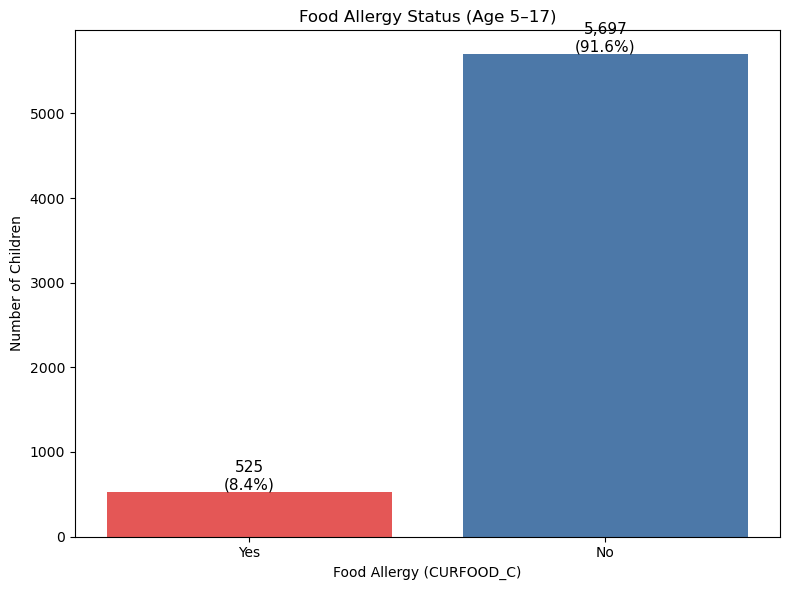

In [9]:
food_series = pd.to_numeric(
    children_with_age_range["CURFOOD_C"], errors="coerce"
)
food_series = food_series[food_series.isin([1, 2])]

# count
counts = food_series.value_counts().reindex([1, 2], fill_value=0)

# percentage
percentages = (counts / counts.sum()) * 100

# labels & colors
labels = ["Yes", "No"]
colors = ["#E45756", "#4C78A8"]

# graph
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts.values, color=colors)

# count + percentage
for bar, count, pct in zip(bars, counts.values, percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count):,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Food Allergy Status (Age 5–17)")
plt.xlabel("Food Allergy (CURFOOD_C)")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()

- The number of children having food allergy by sex
- The number of children having food allergy by age
- The number of children having food allergy by race/ethnicity

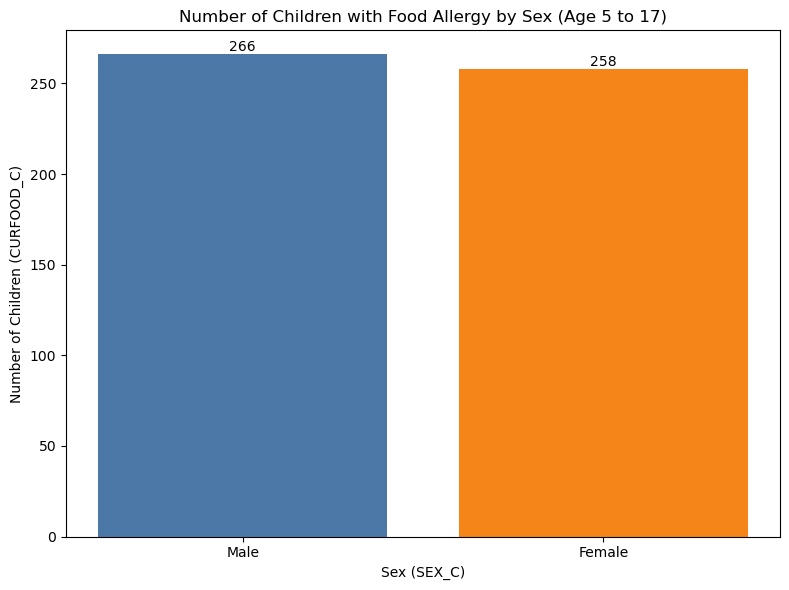

In [10]:
# The number of children having food allergy by sex (Male/Female only, age 5-17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep only Male(1), Female(2)
sex_series = pd.to_numeric(allergy_yes["SEX_C"], errors="coerce")
sex_series = sex_series[sex_series.isin([1, 2])]

# Fixed order: Male, Female
sex_counts = sex_series.value_counts().reindex([1, 2], fill_value=0)
sex_labels = ["Male", "Female"]
bar_colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Sex (Age 5 to 17)")
plt.xlabel("Sex (SEX_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()


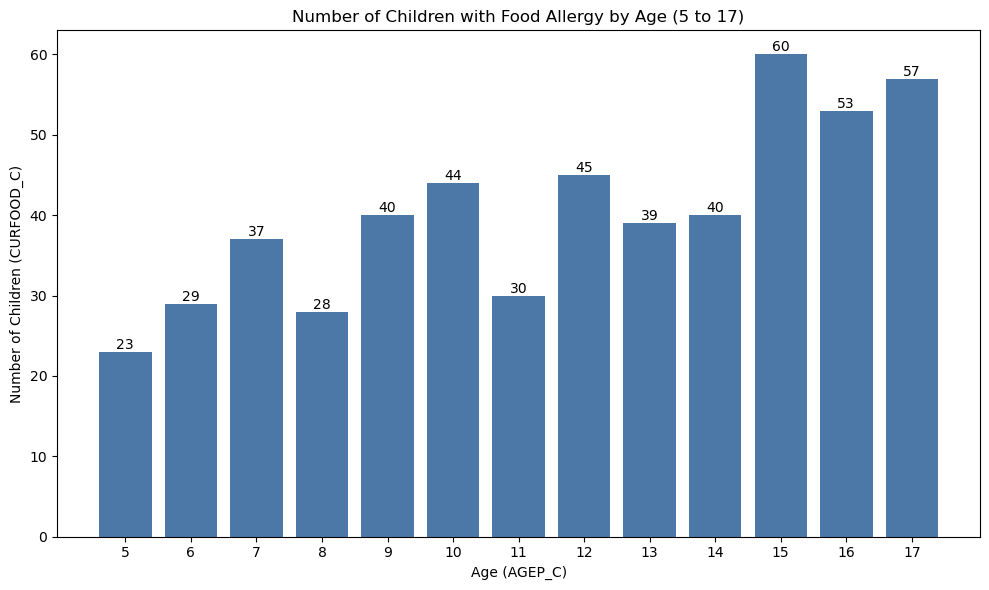

In [11]:
# The number of children having food allergy by age (5 to 17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep valid ages 5-17
age_series = pd.to_numeric(allergy_yes["AGEP_C"], errors="coerce")
age_series = age_series[age_series.between(5, 17)]

# Fixed age order 5~17, fill missing ages with 0
age_counts = age_series.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts on bars
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Age (5 to 17)")
plt.xlabel("Age (AGEP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()

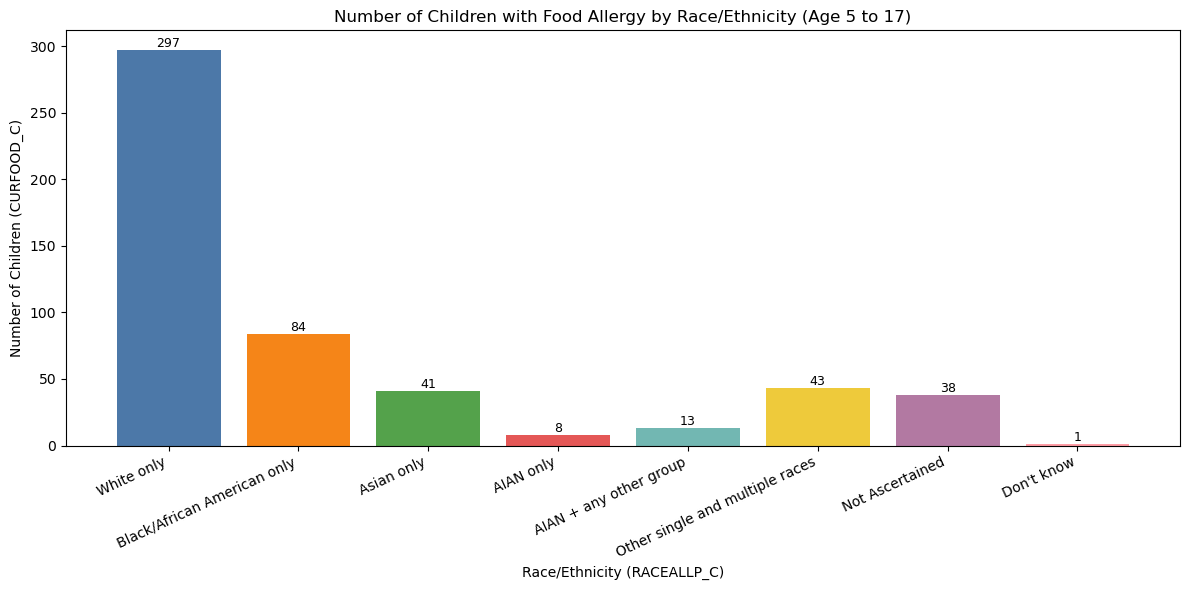

In [12]:
# The number of children having food allergy by race/ethnicity (age 5 to 17)

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Count by race/ethnicity
race_series = pd.to_numeric(allergy_yes["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children with Food Allergy by Race/Ethnicity (Age 5 to 17)")
plt.xlabel("Race/Ethnicity (RACEALLP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
